In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import scipy.stats as stats
from scipy.stats import fisher_exact

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path(r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords")

DATA_PATH = PROJECT_ROOT / "data" / "final_analysis_dataset_ver2.xlsx"

OUTPUT_DIR = PROJECT_ROOT / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"

for path in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, INTERIM_DIR]:
    path.mkdir(parents=True, exist_ok=True)

df = pd.read_excel(DATA_PATH)

print("Dataset shape:", df.shape)
print("File exists:", DATA_PATH.exists())

Dataset shape: (153, 214)
File exists: True


In [2]:
DICOR_VARS = [
    "dicor_ssou_cv_pct",
    "dicor_sm_kdtr_cv_pct",
]

for col in DICOR_VARS:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")

dicor_df = df.dropna(subset=DICOR_VARS).copy()

print("DICOR cohort shape:", dicor_df.shape)

display(dicor_df[DICOR_VARS].describe().T)

DICOR cohort shape: (68, 214)


,count,mean,std,min,25%,50%,75%,max
dicor_ssou_cv_pct,68.0,28.842167,13.328932,9.367687,19.865864,24.270209,36.983409,68.894873
dicor_sm_kdtr_cv_pct,68.0,20.919897,19.035181,0.000000,10.109597,15.505850,23.458813,106.066017


In [3]:
oblique_cols = [
    "lv_false_tendon_apical_oblique_count",
    "lv_false_tendon_mid_oblique_count",
    "lv_false_tendon_basal_oblique_count",
    "lv_false_tendon_mid_to_basal_oblique_count",
    "lv_false_tendon_mid_to_apical_oblique_count",
    "lv_false_tendon_basal_to_apical_oblique_count",
]

transverse_cols = [
    "lv_false_tendon_apical_transverse_count",
    "lv_false_tendon_mid_transverse_count",
    "lv_false_tendon_mid_and_basal_transverse_count",
    "lv_false_tendon_basal_transverse_count",
]

for col in oblique_cols + transverse_cols:
    if col not in dicor_df.columns:
        raise ValueError(f"Missing column: {col}")
    dicor_df[col] = dicor_df[col].fillna(0)

dicor_df["oblique_total"] = dicor_df[oblique_cols].sum(axis=1)
dicor_df["transverse_total"] = dicor_df[transverse_cols].sum(axis=1)

dicor_df["Chord_Orientation"] = np.select(
    [
        dicor_df["transverse_total"] > 0,
        (dicor_df["transverse_total"] == 0) & (dicor_df["oblique_total"] > 0),
    ],
    [
        "Transverse-Involved",
        "Oblique-Only",
    ],
    default="Unclassified"
)

zone_cols = {
    "apical": [
        "lv_false_tendon_apical_oblique_count",
        "lv_false_tendon_apical_transverse_count",
        "lv_false_tendon_mid_to_apical_oblique_count",
        "lv_false_tendon_basal_to_apical_oblique_count",
    ],
    "mid": [
        "lv_false_tendon_mid_oblique_count",
        "lv_false_tendon_mid_transverse_count",
        "lv_false_tendon_mid_and_basal_transverse_count",
        "lv_false_tendon_mid_to_basal_oblique_count",
        "lv_false_tendon_mid_to_apical_oblique_count",
    ],
    "basal": [
        "lv_false_tendon_basal_oblique_count",
        "lv_false_tendon_basal_transverse_count",
        "lv_false_tendon_mid_and_basal_transverse_count",
        "lv_false_tendon_mid_to_basal_oblique_count",
        "lv_false_tendon_basal_to_apical_oblique_count",
    ],
}

for zone, cols in zone_cols.items():
    dicor_df[f"{zone}_zone_present"] = (dicor_df[cols].fillna(0).sum(axis=1) > 0).astype(int)

dicor_df["n_zones_involved"] = dicor_df[
    ["apical_zone_present", "mid_zone_present", "basal_zone_present"]
].sum(axis=1)

def classify_spread(row):
    active = []
    for zone in ["apical", "mid", "basal"]:
        if row[f"{zone}_zone_present"] == 1:
            active.append(zone)

    if len(active) == 0:
        return "Unclassified"
    if len(active) == 1:
        return "Same Region"
    if len(active) == 2:
        if set(active) in [set(["apical", "mid"]), set(["mid", "basal"])]:
            return "Adjacent Regions"
        if set(active) == set(["apical", "basal"]):
            return "Distant Regions"
    if len(active) == 3:
        return "Distant Regions"
    return "Unclassified"

dicor_df["Chord_Spread_Class"] = dicor_df.apply(classify_spread, axis=1)

print("Orientation:")
display(dicor_df["Chord_Orientation"].value_counts(dropna=False).to_frame("n"))

print("Spread:")
display(dicor_df["Chord_Spread_Class"].value_counts(dropna=False).to_frame("n"))

Orientation:


,n
Chord_Orientation,
Transverse-Involved,62
Oblique-Only,6


Spread:


,n
Chord_Spread_Class,
Distant Regions,63
Adjacent Regions,5


In [4]:
KDTR_VAR = "dicor_sm_kdtr_cv_pct"

kdtr_threshold = dicor_df[KDTR_VAR].quantile(0.85)

dicor_df["Extreme_KDTR_Phenotype"] = np.where(
    dicor_df[KDTR_VAR] >= kdtr_threshold,
    "Extreme-KDTR",
    "Non-Extreme"
)

print("KDTR 85th percentile threshold:", round(kdtr_threshold, 2))

display(dicor_df["Extreme_KDTR_Phenotype"].value_counts().to_frame("n"))

display(
    dicor_df.groupby("Extreme_KDTR_Phenotype")[KDTR_VAR]
    .describe()
)

KDTR 85th percentile threshold: 31.35


,n
Extreme_KDTR_Phenotype,
Non-Extreme,57
Extreme-KDTR,11


,count,mean,std,min,25%,50%,75%,max
Extreme_KDTR_Phenotype,,,,,,,,
Extreme-KDTR,11.0,55.293054,24.031573,31.491833,38.231684,40.809916,71.658793,106.066017
Non-Extreme,57.0,14.286481,7.315235,0.000000,8.000000,14.380637,20.156360,28.571429


In [5]:
dicor_df["Distant_Transverse_Architecture"] = np.where(
    (dicor_df["Chord_Spread_Class"] == "Distant Regions") &
    (dicor_df["Chord_Orientation"] == "Transverse-Involved"),
    "Distant + Transverse",
    "Other classified / unclassified"
)

display(dicor_df["Distant_Transverse_Architecture"].value_counts().to_frame("n"))

combined_table = pd.crosstab(
    dicor_df["Distant_Transverse_Architecture"],
    dicor_df["Extreme_KDTR_Phenotype"]
)

display(combined_table)

combined_prop = combined_table.div(combined_table.sum(axis=1), axis=0)

display(combined_prop)

,n
Distant_Transverse_Architecture,
Distant + Transverse,58
Other classified / unclassified,10


Extreme_KDTR_Phenotype,Extreme-KDTR,Non-Extreme
Distant_Transverse_Architecture,,
Distant + Transverse,11,47
Other classified / unclassified,0,10


Extreme_KDTR_Phenotype,Extreme-KDTR,Non-Extreme
Distant_Transverse_Architecture,,
Distant + Transverse,0.189655,0.810345
Other classified / unclassified,0.000000,1.000000


In [6]:
# 2x2 table for Fisher
# Rows: Distant+Transverse vs Other
# Columns: Extreme vs Non-Extreme

table = pd.crosstab(
    dicor_df["Distant_Transverse_Architecture"],
    dicor_df["Extreme_KDTR_Phenotype"]
)

# Reorder
table = table.loc[
    ["Distant + Transverse", "Other classified / unclassified"],
    ["Extreme-KDTR", "Non-Extreme"]
]

display(table)

odds_ratio, fisher_p = fisher_exact(table)

risk_high = table.loc["Distant + Transverse", "Extreme-KDTR"] / table.loc["Distant + Transverse"].sum()
risk_other = table.loc["Other classified / unclassified", "Extreme-KDTR"] / table.loc["Other classified / unclassified"].sum()
risk_difference = risk_high - risk_other

print("Fisher exact test")
print("Odds ratio:", odds_ratio)
print("p-value:", round(fisher_p, 4))

print("\nRisk")
print("Risk in Distant + Transverse:", round(risk_high, 3))
print("Risk in Other:", round(risk_other, 3))
print("Risk difference:", round(risk_difference, 3))

Extreme_KDTR_Phenotype,Extreme-KDTR,Non-Extreme
Distant_Transverse_Architecture,,
Distant + Transverse,11,47
Other classified / unclassified,0,10


Fisher exact test
Odds ratio: inf
p-value: 0.197

Risk
Risk in Distant + Transverse: 0.19
Risk in Other: 0.0
Risk difference: 0.19


C:\Users\Ars\AppData\Local\Temp\ipykernel_28176\2315714514.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


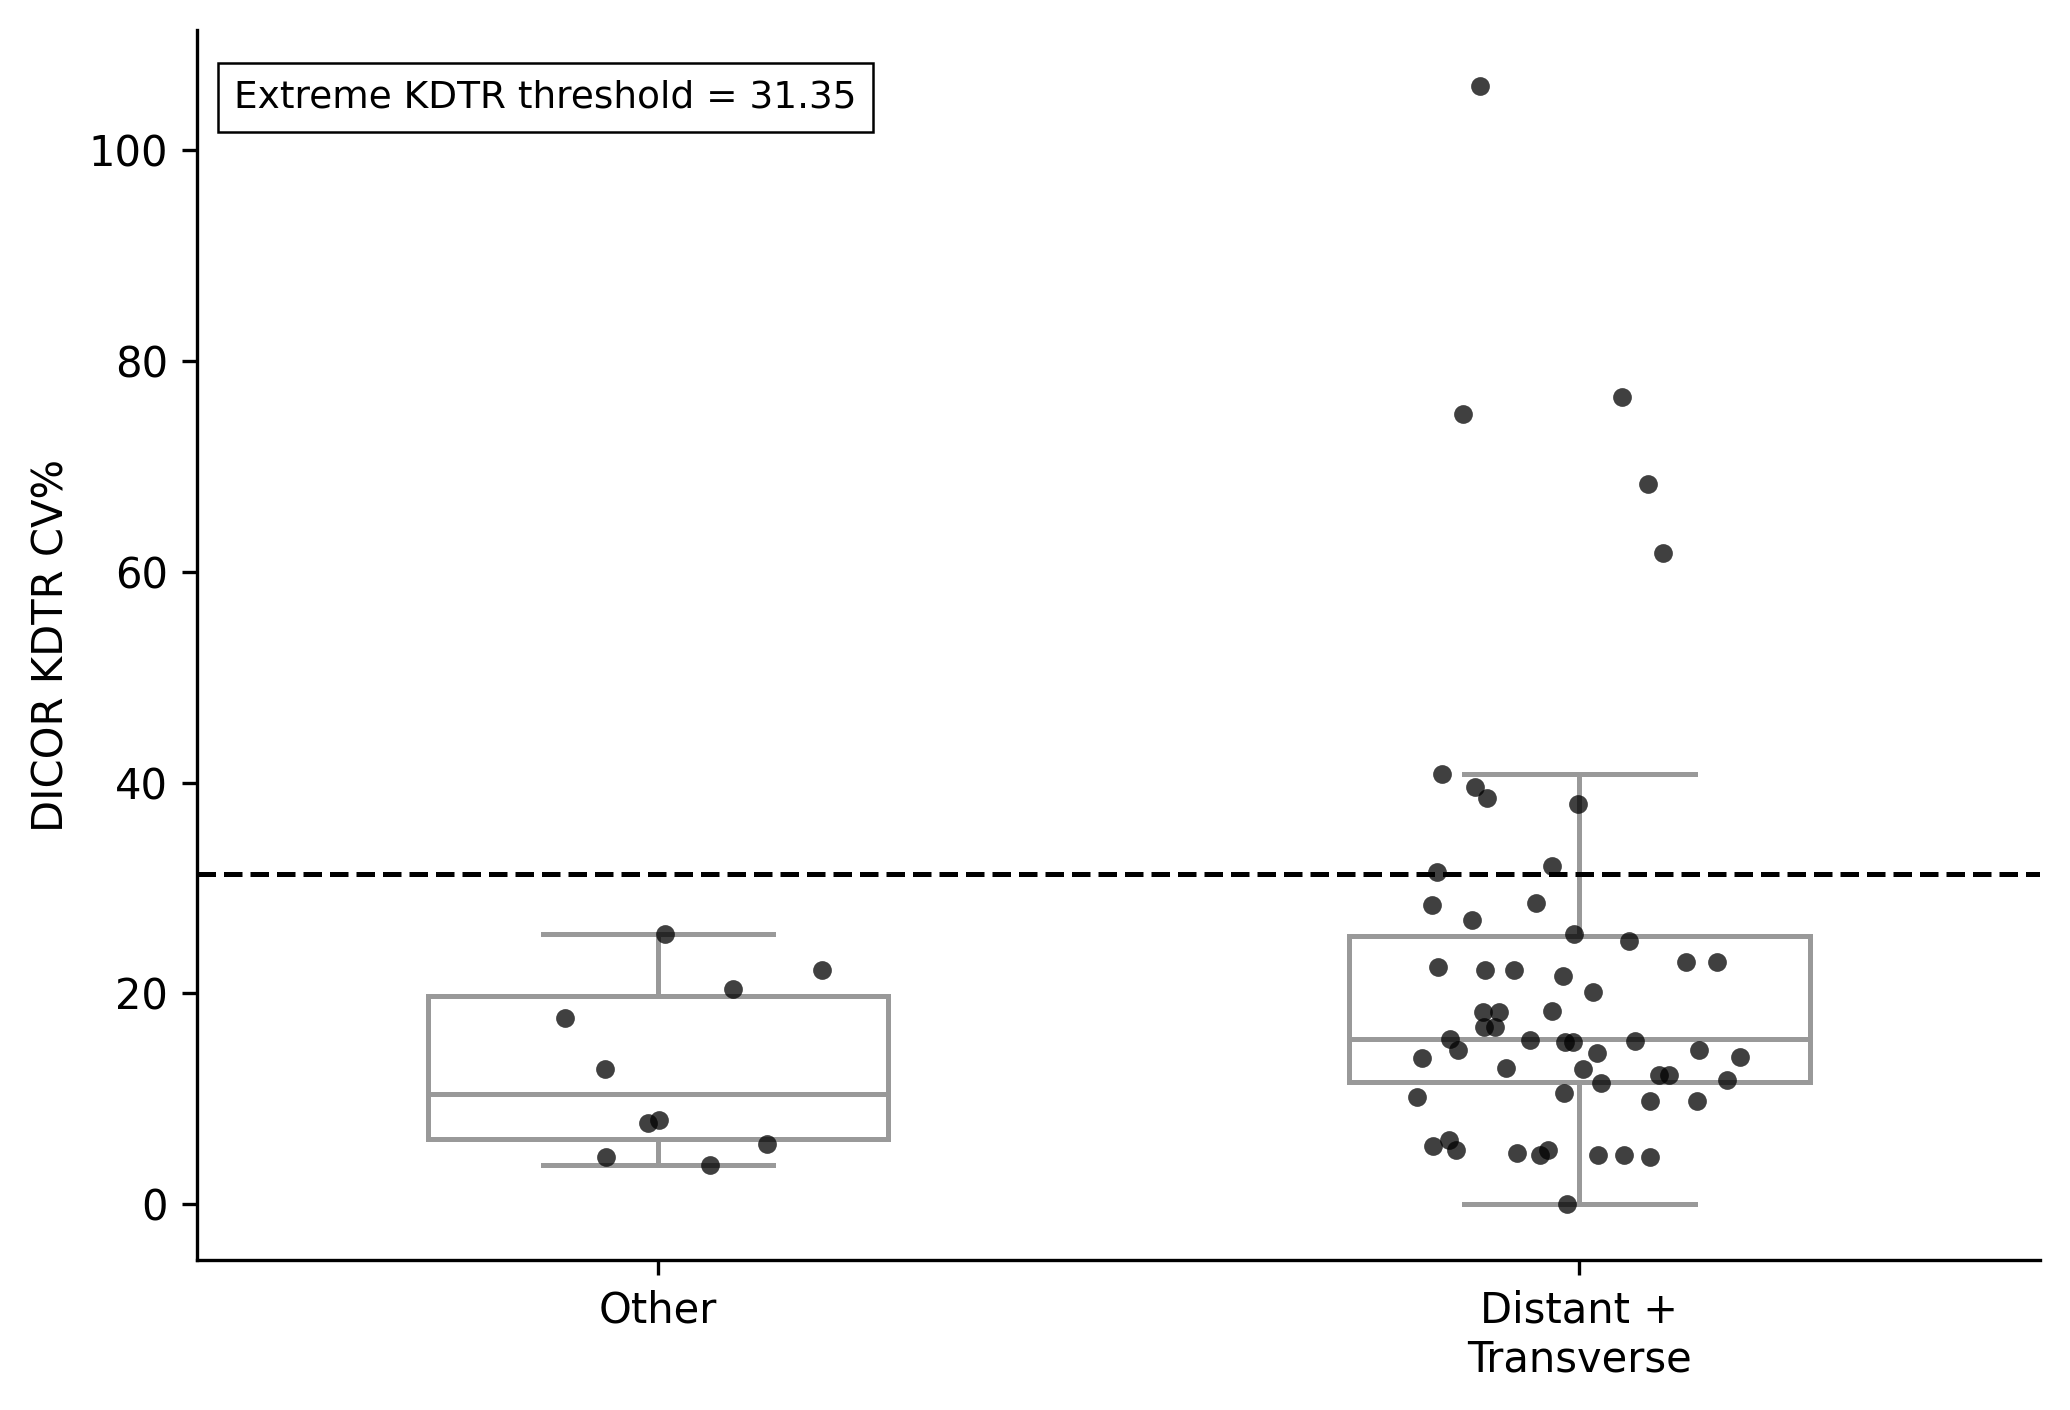

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\07_kdtr_by_distant_transverse_architecture.png


In [7]:
plot_df = dicor_df.copy()

order = [
    "Other classified / unclassified",
    "Distant + Transverse",
]

plt.figure(figsize=(7, 4.8), dpi=300)

ax = sns.boxplot(
    data=plot_df,
    x="Distant_Transverse_Architecture",
    y=KDTR_VAR,
    order=order,
    showfliers=False,
    width=0.5,
    color="white",
    linewidth=1.2,
)

sns.stripplot(
    data=plot_df,
    x="Distant_Transverse_Architecture",
    y=KDTR_VAR,
    order=order,
    color="black",
    size=4.5,
    jitter=0.18,
    alpha=0.75,
)

ax.axhline(
    kdtr_threshold,
    color="black",
    linestyle="--",
    linewidth=1.2,
)

ax.text(
    0.02,
    0.96,
    f"Extreme KDTR threshold = {kdtr_threshold:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox={"facecolor": "white", "edgecolor": "black", "linewidth": 0.6}
)

ax.set_xlabel("")
ax.set_ylabel("DICOR KDTR CV%")

ax.set_xticklabels([
    "Other",
    "Distant +\nTransverse"
])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig_path = FIGURES_DIR / "07_kdtr_by_distant_transverse_architecture.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

,Distant_Transverse_Architecture,count,group_n,proportion
0,Other classified / unclassified,0,10,0.000000
1,Distant + Transverse,11,58,0.189655


C:\Users\Ars\AppData\Local\Temp\ipykernel_28176\4044252426.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


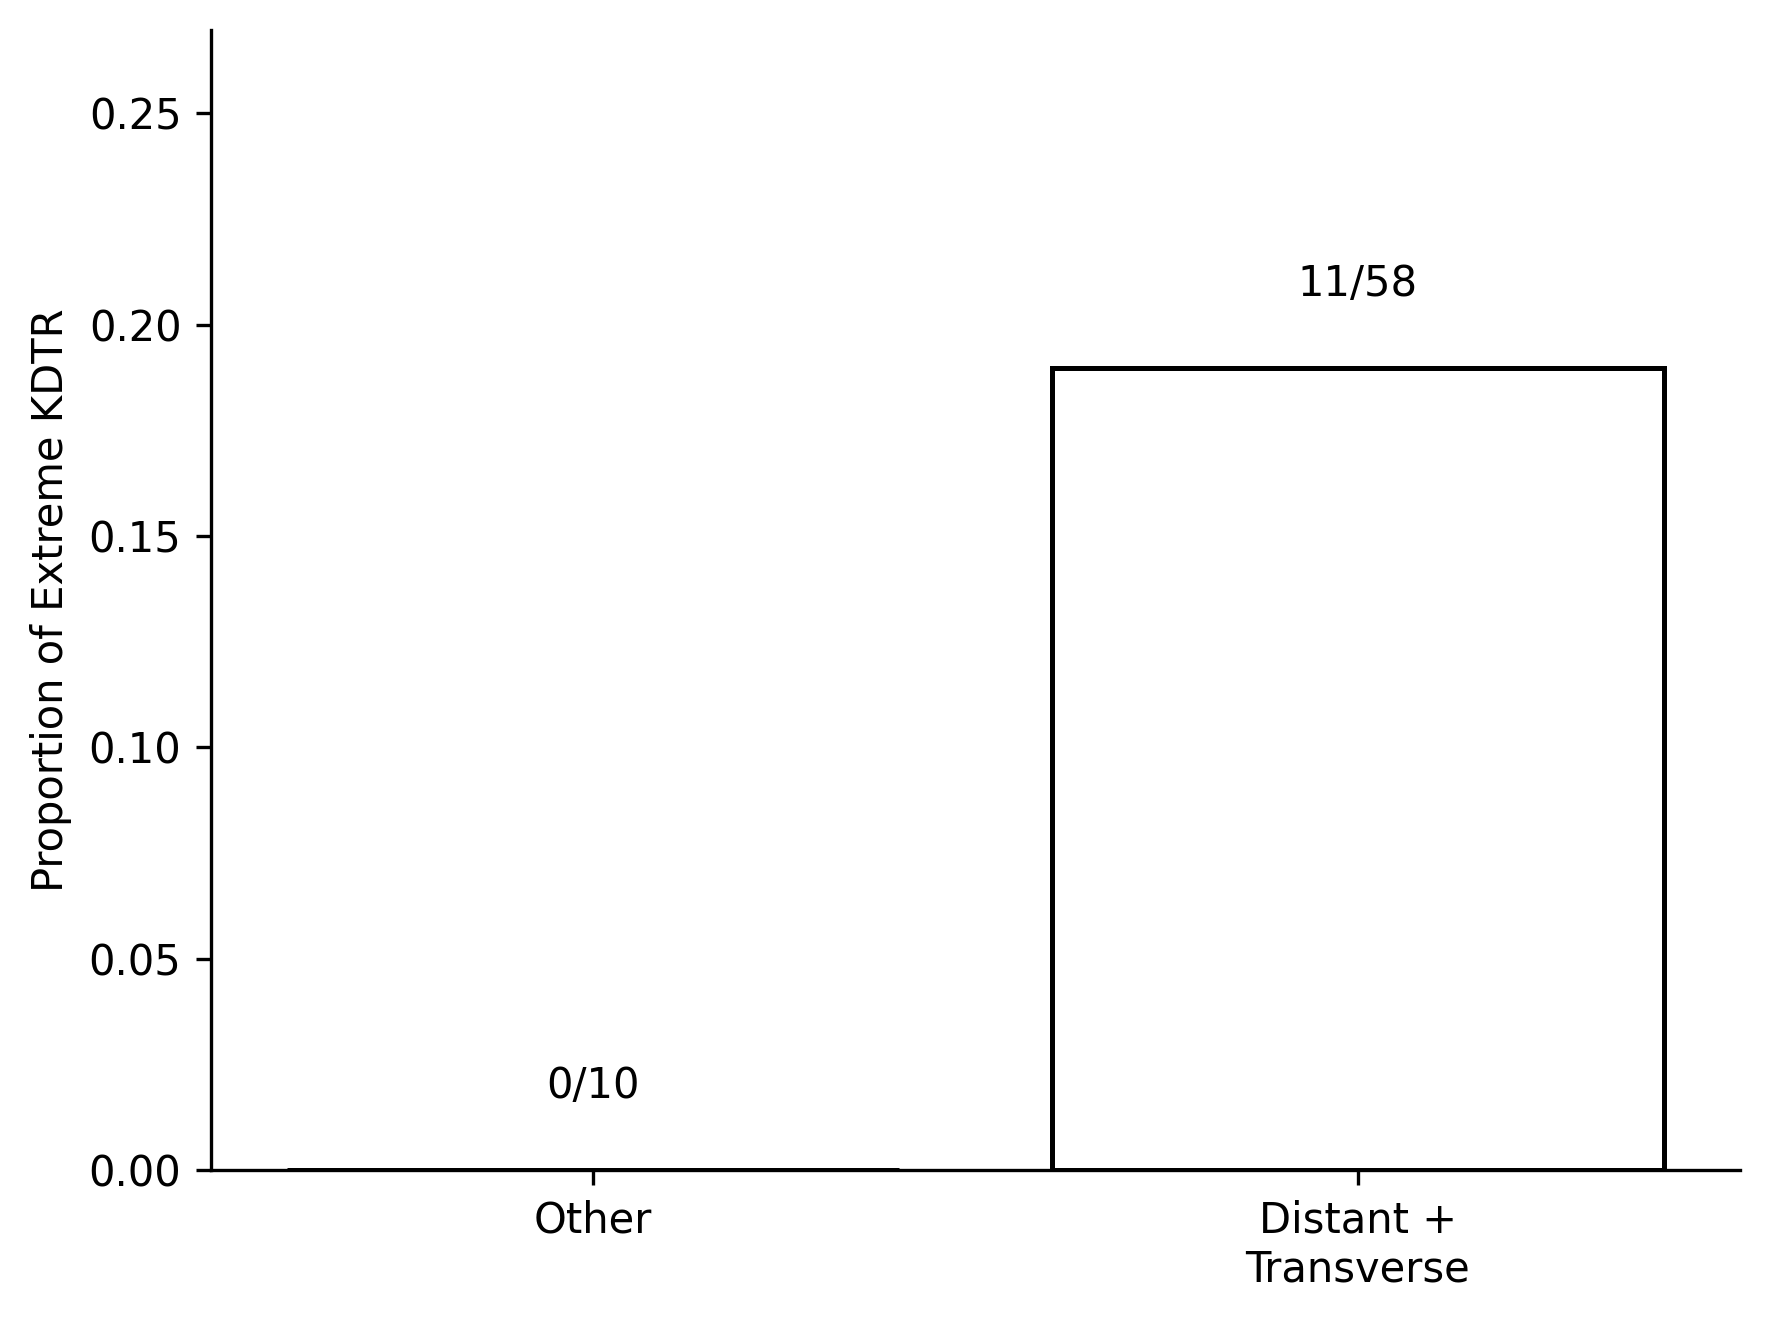

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\07_extreme_kdtr_proportion_by_architecture.png


In [11]:
# ==========================================
# Proportion plot with explicit zero groups
# ==========================================

order = [
    "Other classified / unclassified",
    "Distant + Transverse",
]

# Total n per group
group_n = (
    dicor_df
    .groupby("Distant_Transverse_Architecture")
    .size()
    .reindex(order, fill_value=0)
)

# Extreme n per group
extreme_n = (
    dicor_df[dicor_df["Extreme_KDTR_Phenotype"] == "Extreme-KDTR"]
    .groupby("Distant_Transverse_Architecture")
    .size()
    .reindex(order, fill_value=0)
)

plot_prop = pd.DataFrame({
    "Distant_Transverse_Architecture": order,
    "count": extreme_n.values,
    "group_n": group_n.values,
})

plot_prop["proportion"] = np.where(
    plot_prop["group_n"] > 0,
    plot_prop["count"] / plot_prop["group_n"],
    np.nan,
)

display(plot_prop)

plt.figure(figsize=(6, 4.5), dpi=300)

ax = sns.barplot(
    data=plot_prop,
    x="Distant_Transverse_Architecture",
    y="proportion",
    order=order,
    color="white",
    edgecolor="black",
    linewidth=1.2,
)

for i, row in plot_prop.iterrows():
    y_pos = row["proportion"] + 0.015 if row["proportion"] > 0 else 0.015
    
    ax.text(
        i,
        y_pos,
        f"{int(row['count'])}/{int(row['group_n'])}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black"
    )

ax.set_ylim(0, max(plot_prop["proportion"].max() + 0.08, 0.2))

ax.set_xlabel("")
ax.set_ylabel("Proportion of Extreme KDTR")

ax.set_xticklabels([
    "Other",
    "Distant +\nTransverse"
])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig_path = FIGURES_DIR / "07_extreme_kdtr_proportion_by_architecture.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

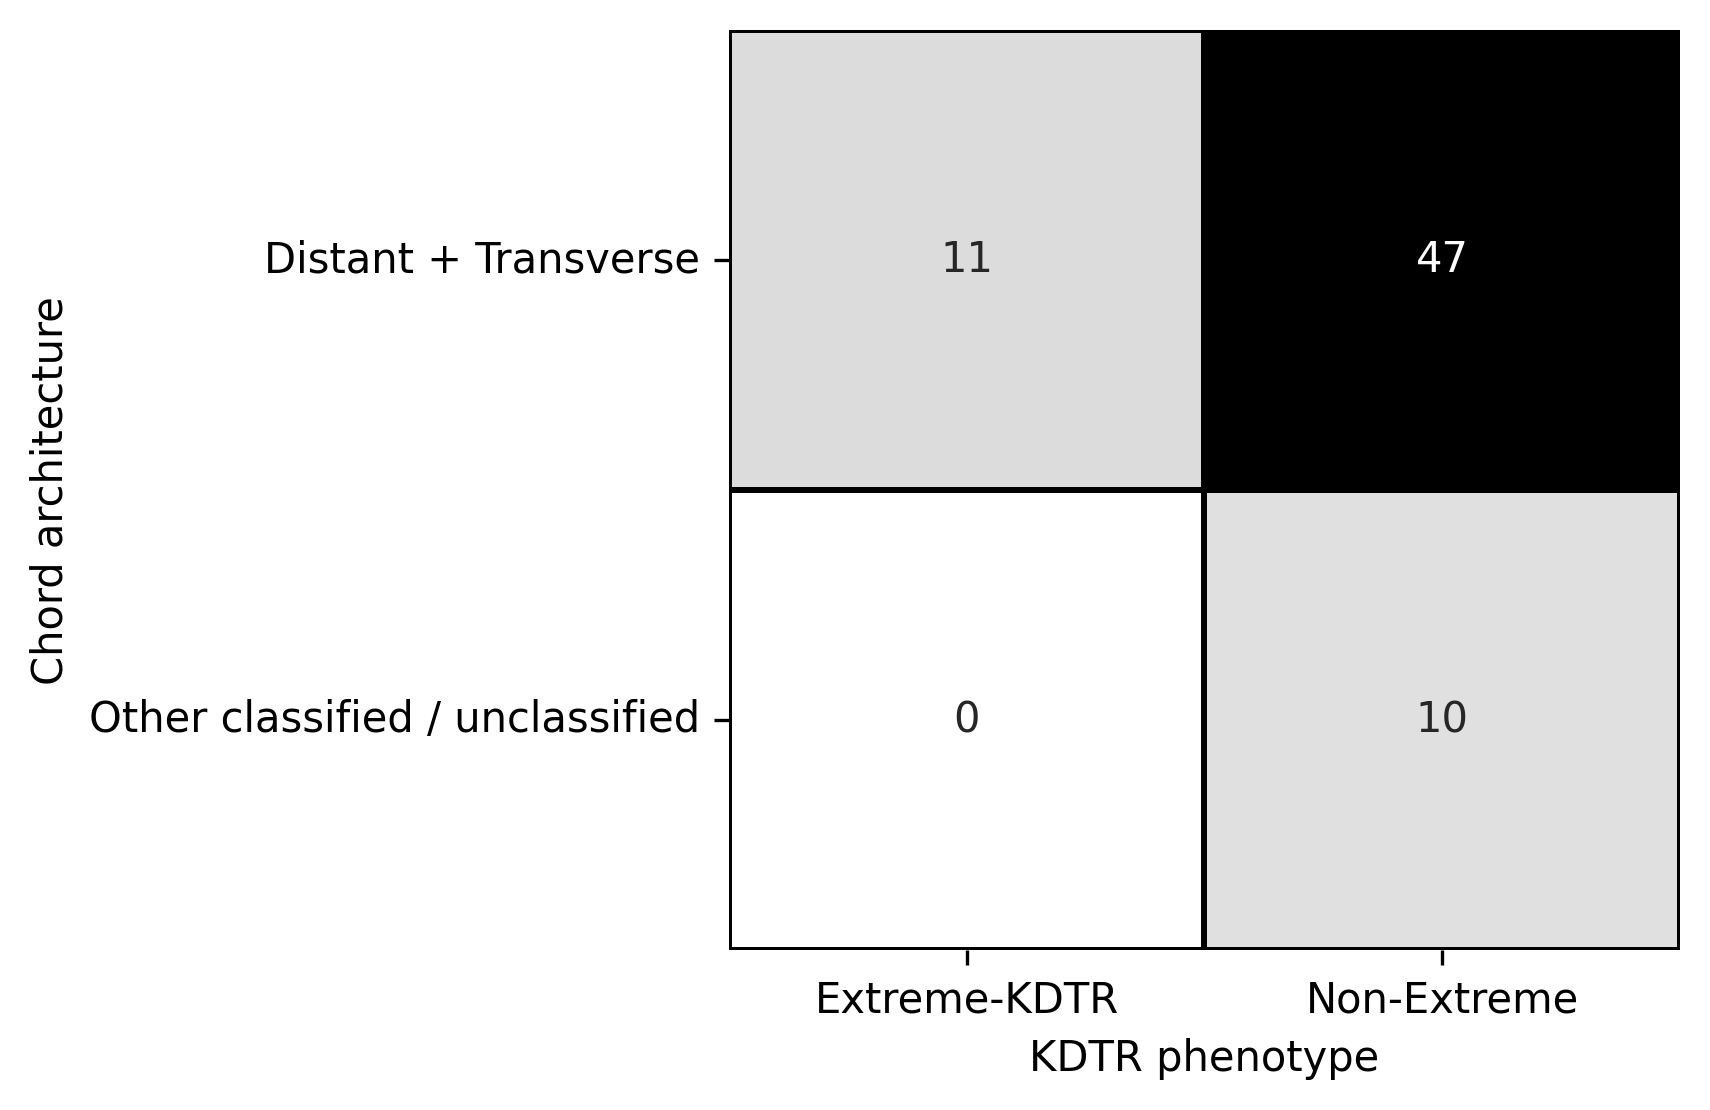

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\07_contingency_heatmap_architecture_extreme_kdtr.png


In [9]:
heatmap_table = table.copy()

plt.figure(figsize=(5.8, 3.8), dpi=300)

ax = sns.heatmap(
    heatmap_table,
    annot=True,
    fmt="d",
    cmap="Greys",
    linewidths=1,
    linecolor="black",
    cbar=False
)

ax.set_xlabel("KDTR phenotype")
ax.set_ylabel("Chord architecture")

plt.tight_layout()

fig_path = FIGURES_DIR / "07_contingency_heatmap_architecture_extreme_kdtr.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [10]:
summary_rows = []

summary_rows.append({
    "analysis": "Extreme KDTR threshold",
    "value": kdtr_threshold,
})

summary_rows.append({
    "analysis": "Fisher exact p-value",
    "value": fisher_p,
})

summary_rows.append({
    "analysis": "Odds ratio",
    "value": odds_ratio,
})

summary_rows.append({
    "analysis": "Risk in Distant + Transverse",
    "value": risk_high,
})

summary_rows.append({
    "analysis": "Risk in Other",
    "value": risk_other,
})

summary_rows.append({
    "analysis": "Risk difference",
    "value": risk_difference,
})

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

OUT_DATA = INTERIM_DIR / "07_dicor_extreme_kdtr_chord_architecture_dataset.xlsx"
OUT_SUMMARY = TABLES_DIR / "07_dicor_extreme_kdtr_chord_architecture_summary.xlsx"
OUT_TABLE = TABLES_DIR / "07_dicor_extreme_kdtr_contingency_table.xlsx"

dicor_df.to_excel(OUT_DATA, index=False)
summary_df.to_excel(OUT_SUMMARY, index=False)
table.to_excel(OUT_TABLE)

print("Saved:")
print(OUT_DATA)
print(OUT_SUMMARY)
print(OUT_TABLE)

,analysis,value
0,Extreme KDTR threshold,31.345813
1,Fisher exact p-value,0.197023
2,Odds ratio,inf
3,Risk in Distant + Transverse,0.189655
4,Risk in Other,0.000000
5,Risk difference,0.189655


Saved:
C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\interim\07_dicor_extreme_kdtr_chord_architecture_dataset.xlsx
C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\tables\07_dicor_extreme_kdtr_chord_architecture_summary.xlsx
C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\tables\07_dicor_extreme_kdtr_contingency_table.xlsx


## Additional check: LV geometry and Extreme KDTR phenotype

At this stage, the key exploratory finding is that the Extreme-KDTR phenotype appears only within the Distant + Transverse chord architecture group. 

Before moving to cross-modal validation, we additionally check whether Extreme-KDTR is simply a reflection of LV geometry rather than chord architecture.

This is important because if Extreme-KDTR is fully explained by LV size or sphericity, the chord architecture hypothesis becomes weaker. If geometry does not fully separate the groups, the result remains more consistent with a mechanical/topological chord effect.

In [12]:
# ==========================================
# LV geometry check for Extreme KDTR phenotype
# ==========================================

geometry_vars = [
    "echo_lv_sphericity_index_end_systolic_ratio",
    "echo_lv_sphericity_index_end_diastolic_ratio",
    "echo_lv_end_systolic_diameter_mm",
    "echo_lv_end_diastolic_diameter_mm",
    "echo_lv_end_systolic_volume_ml",
    "echo_lv_end_diastolic_volume_ml",
    "echo_lv_ejection_fraction_pct",
]

geometry_vars = [v for v in geometry_vars if v in dicor_df.columns]

print("Available geometry variables:")
print(geometry_vars)

geometry_results = []

for var in geometry_vars:
    d = dicor_df[[var, "Extreme_KDTR_Phenotype"]].dropna().copy()
    
    if d["Extreme_KDTR_Phenotype"].nunique() < 2:
        continue
    
    y_extreme = d.loc[d["Extreme_KDTR_Phenotype"] == "Extreme-KDTR", var]
    y_non = d.loc[d["Extreme_KDTR_Phenotype"] == "Non-Extreme", var]
    
    try:
        test = stats.mannwhitneyu(y_extreme, y_non, alternative="two-sided")
        p_value = test.pvalue
    except Exception:
        p_value = np.nan
    
    geometry_results.append({
        "variable": var,
        "n_extreme": len(y_extreme),
        "n_non_extreme": len(y_non),
        "mean_extreme": y_extreme.mean(),
        "mean_non_extreme": y_non.mean(),
        "median_extreme": y_extreme.median(),
        "median_non_extreme": y_non.median(),
        "difference_median_extreme_minus_non": y_extreme.median() - y_non.median(),
        "mann_whitney_p": p_value,
    })

geometry_results_df = pd.DataFrame(geometry_results)

display(geometry_results_df)

geometry_results_df.to_excel(
    TABLES_DIR / "07_geometry_vs_extreme_kdtr.xlsx",
    index=False
)

Available geometry variables:
['echo_lv_sphericity_index_end_systolic_ratio', 'echo_lv_sphericity_index_end_diastolic_ratio', 'echo_lv_end_systolic_diameter_mm', 'echo_lv_end_diastolic_diameter_mm']


,variable,n_extreme,n_non_extreme,mean_extreme,mean_non_extreme,median_extreme,median_non_extreme,difference_median_extreme_minus_non,mann_whitney_p
0,echo_lv_sphericity_index_end_systolic_ratio,11,57,0.439455,0.427368,0.439,0.414,0.025,0.278969
1,echo_lv_sphericity_index_end_diastolic_ratio,11,57,0.528455,0.506474,0.535,0.489,0.046,0.156819
2,echo_lv_end_systolic_diameter_mm,11,57,31.909091,30.719298,32.000,30.000,2.000,0.269684
3,echo_lv_end_diastolic_diameter_mm,11,57,49.545455,47.508772,49.000,47.000,2.000,0.248392


C:\Users\Ars\AppData\Local\Temp\ipykernel_28176\198001834.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-Extreme", "Extreme KDTR"])


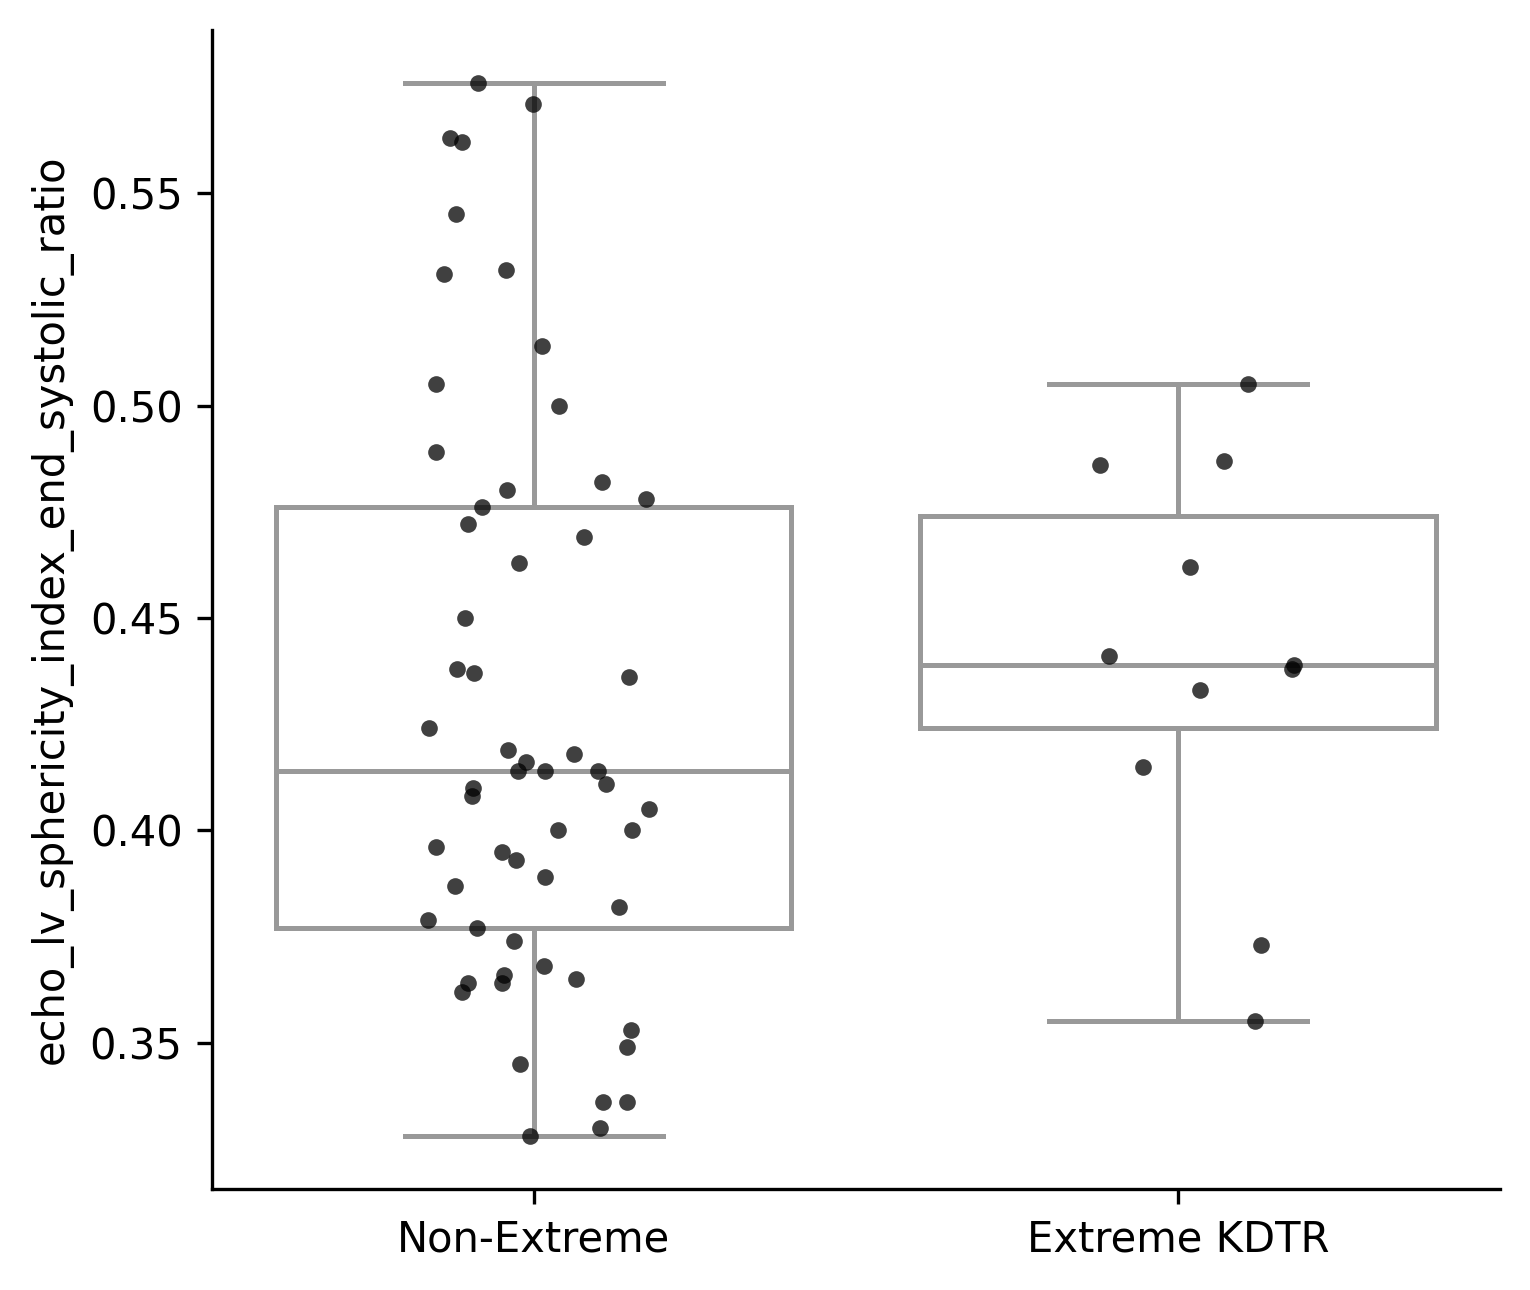

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\07_geometry_echo_lv_sphericity_index_end_systolic_ratio_by_extreme_kdtr.png


C:\Users\Ars\AppData\Local\Temp\ipykernel_28176\198001834.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-Extreme", "Extreme KDTR"])


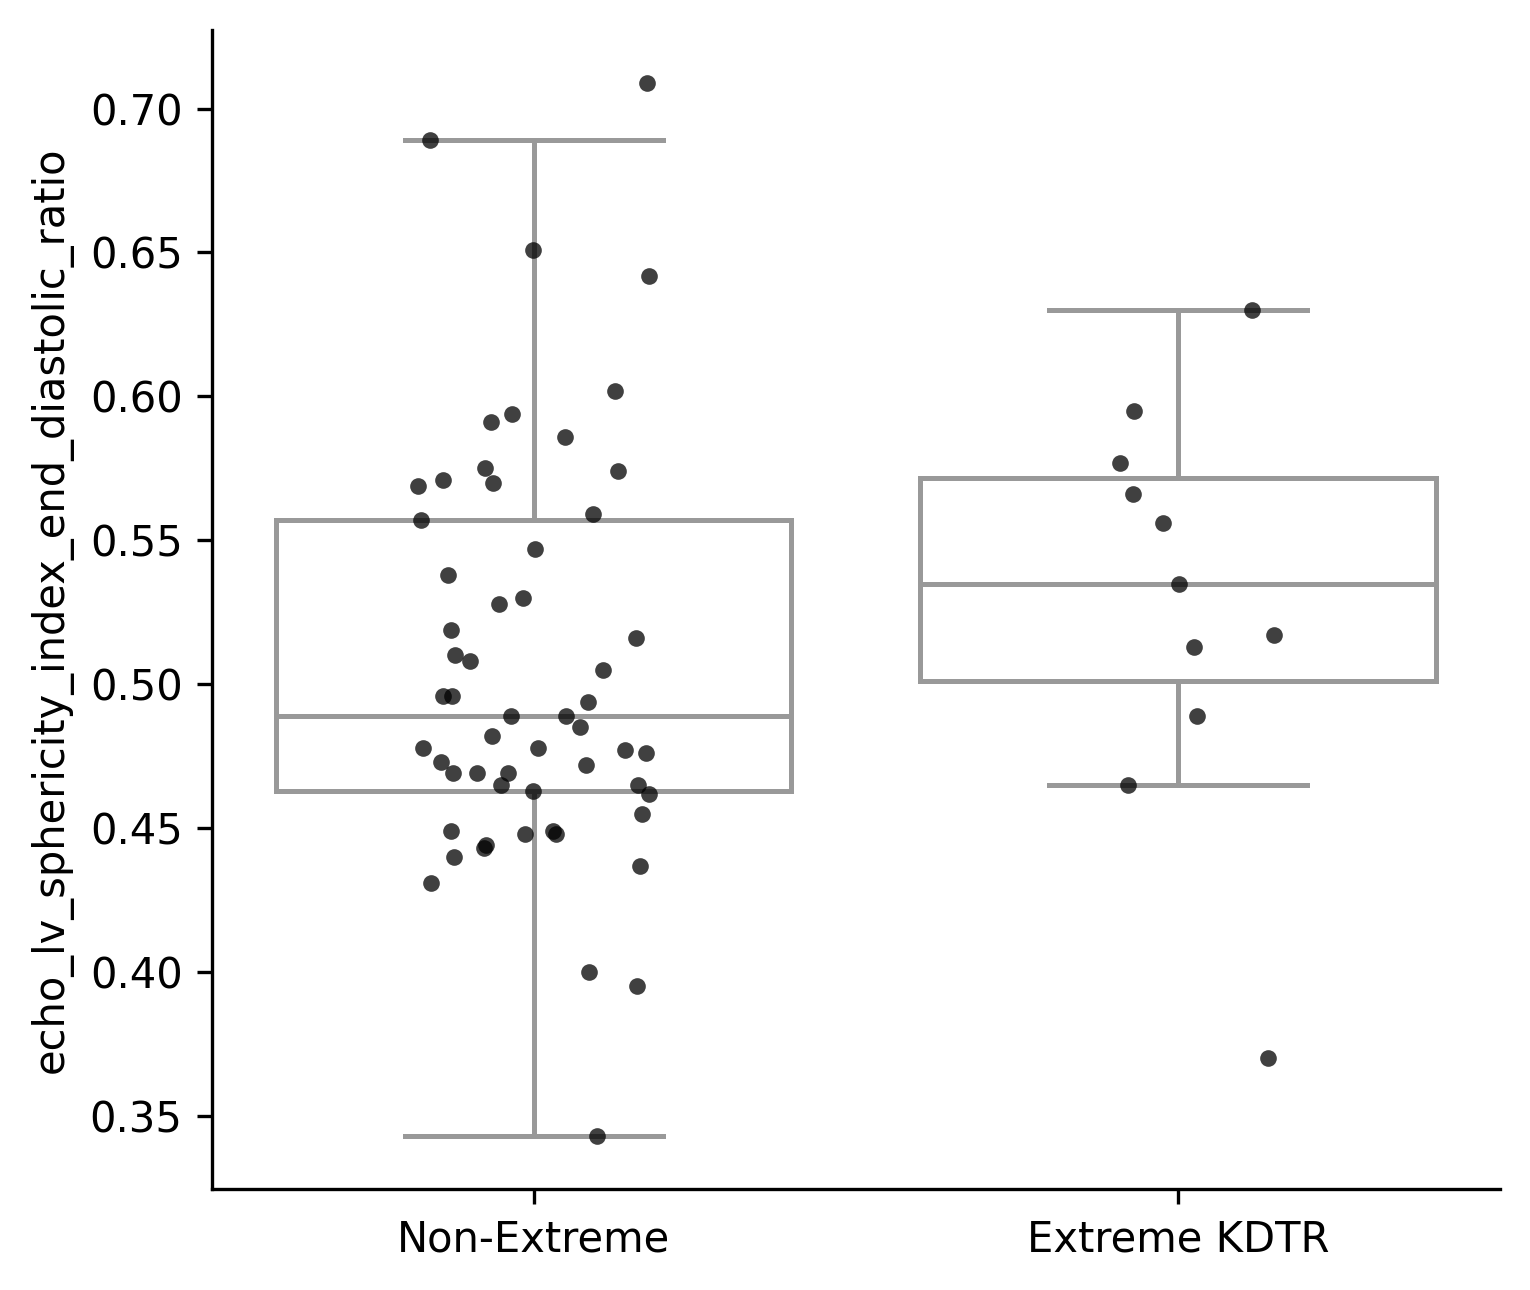

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\07_geometry_echo_lv_sphericity_index_end_diastolic_ratio_by_extreme_kdtr.png


C:\Users\Ars\AppData\Local\Temp\ipykernel_28176\198001834.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-Extreme", "Extreme KDTR"])


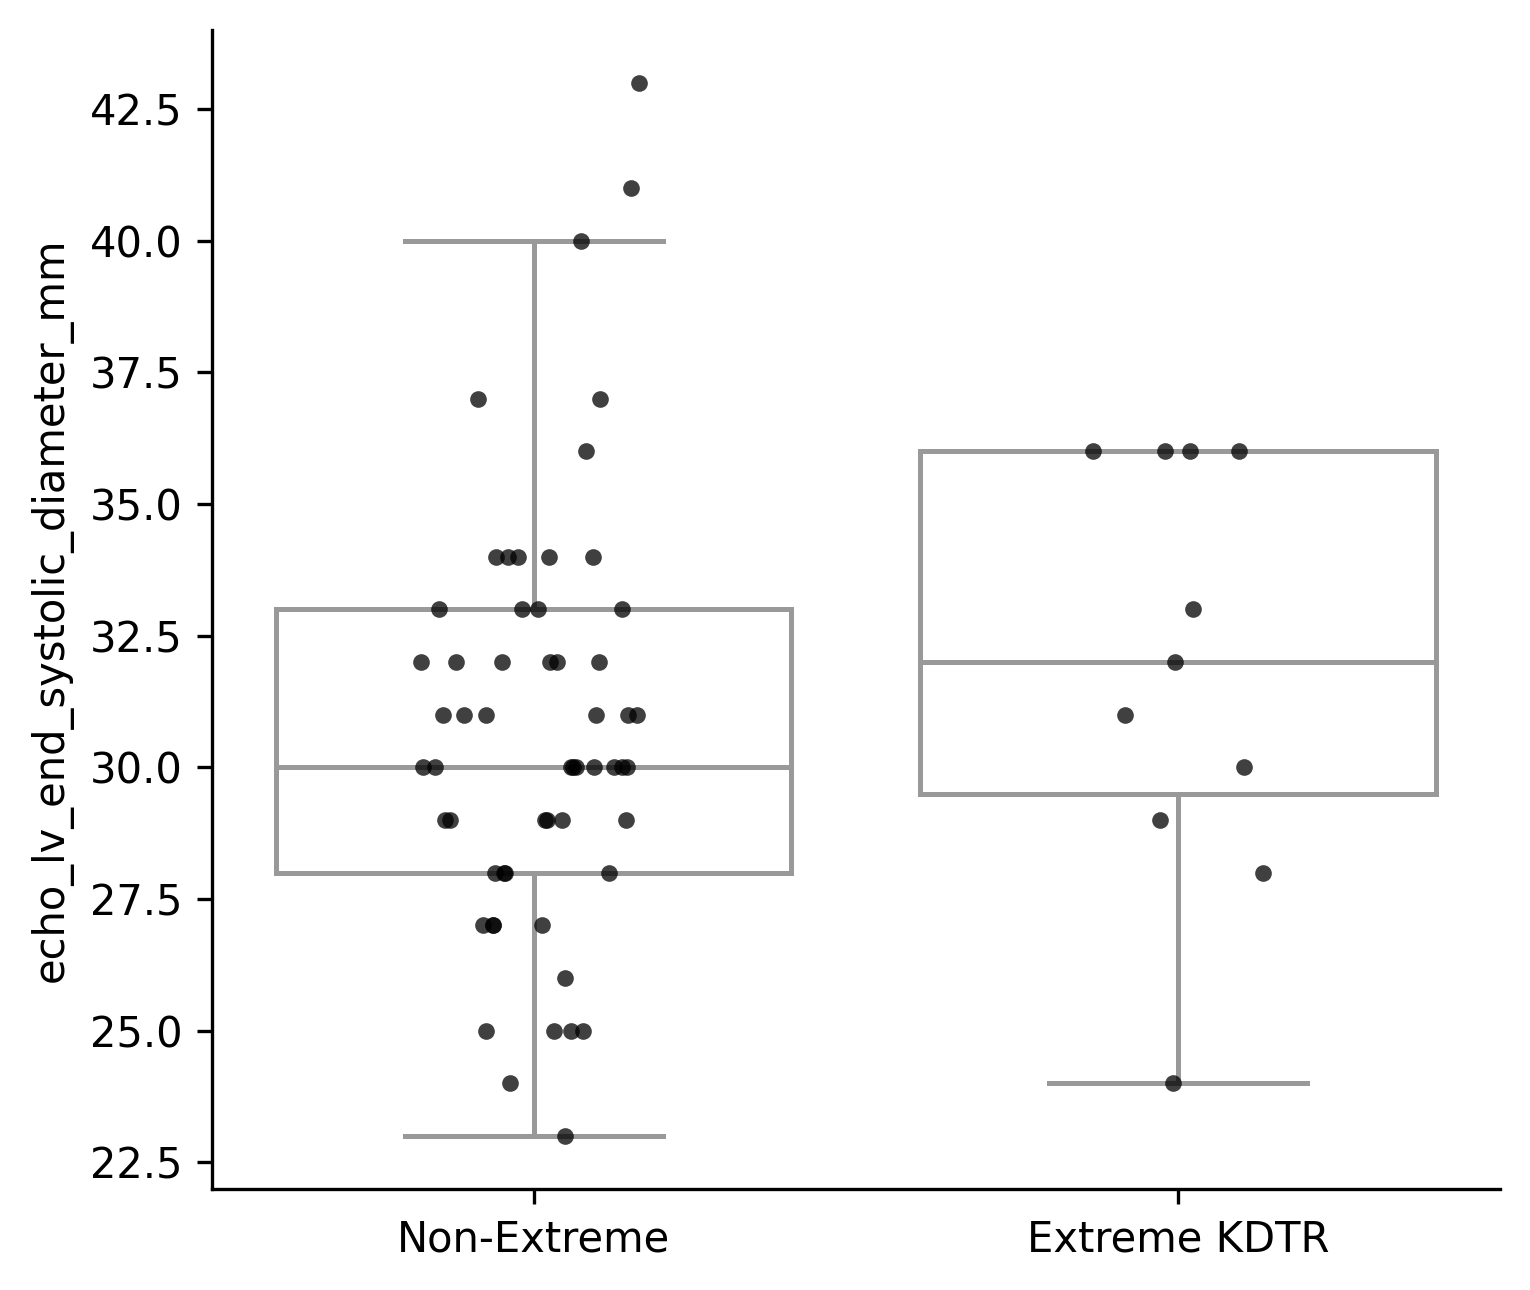

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\07_geometry_echo_lv_end_systolic_diameter_mm_by_extreme_kdtr.png


C:\Users\Ars\AppData\Local\Temp\ipykernel_28176\198001834.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-Extreme", "Extreme KDTR"])


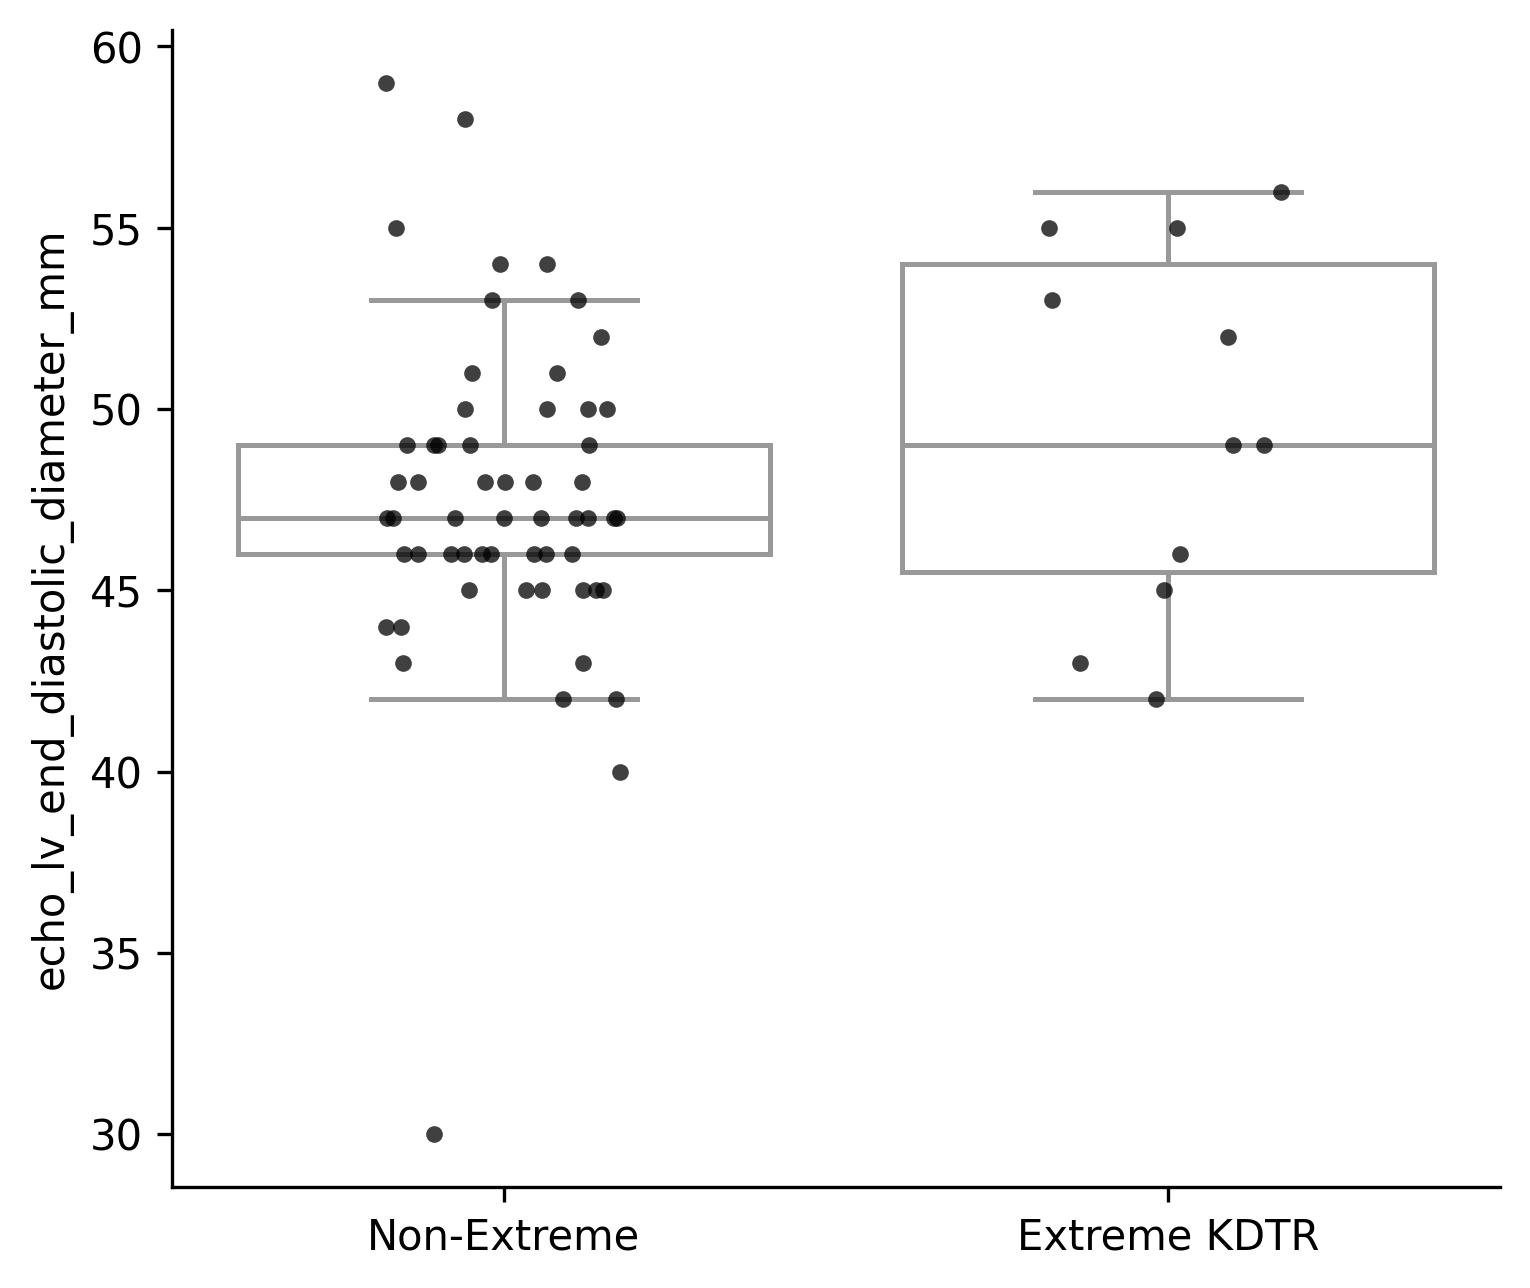

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\07_geometry_echo_lv_end_diastolic_diameter_mm_by_extreme_kdtr.png


In [13]:
# ==========================================
# Geometry visualization
# ==========================================

if len(geometry_vars) > 0:
    for var in geometry_vars:
        d = dicor_df[[var, "Extreme_KDTR_Phenotype"]].dropna().copy()
        
        if d["Extreme_KDTR_Phenotype"].nunique() < 2:
            continue
        
        plt.figure(figsize=(5.2, 4.4), dpi=300)
        
        ax = sns.boxplot(
            data=d,
            x="Extreme_KDTR_Phenotype",
            y=var,
            order=["Non-Extreme", "Extreme-KDTR"],
            color="white",
            linewidth=1.2,
            showfliers=False,
        )
        
        sns.stripplot(
            data=d,
            x="Extreme_KDTR_Phenotype",
            y=var,
            order=["Non-Extreme", "Extreme-KDTR"],
            color="black",
            size=4,
            jitter=0.18,
            alpha=0.75,
        )
        
        ax.set_xlabel("")
        ax.set_ylabel(var)
        ax.set_xticklabels(["Non-Extreme", "Extreme KDTR"])
        
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        plt.tight_layout()
        
        fig_path = FIGURES_DIR / f"07_geometry_{var}_by_extreme_kdtr.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()
        
        print("Saved:", fig_path)

## Summary of Notebook 07

This notebook evaluated whether DICOR-derived diastolic mechanical dispersion is better understood as a continuous variable, a cluster structure, or a heavy-tail phenotype.

The distribution of `dicor_sm_kdtr_cv_pct` demonstrated marked right-skewness and a heavy right tail. Because the data did not show clearly separated Gaussian-like clusters, conventional clustering was not forced. Instead, an Extreme-KDTR phenotype was defined as the upper 15% of the DICOR KDTR CV% distribution.

The Extreme-KDTR threshold was 31.35. This identified 11 patients out of the DICOR cohort of 68. The Extreme-KDTR group had a much higher median KDTR CV% than the non-extreme group, suggesting that this is not a single outlier but a small high-dispersion mechanical phenotype.

The key exploratory finding was that all Extreme-KDTR cases occurred within the Distant + Transverse chord architecture group. In contrast, no Extreme-KDTR cases were observed in the Other architecture group. The estimated risk of Extreme-KDTR was approximately 19% in the Distant + Transverse group and 0% in the Other group. Fisher’s exact test was not statistically significant, which is expected given the sparse 2×2 table and small number of extreme cases. Therefore, this result should be interpreted as an exploratory enrichment signal rather than confirmatory evidence.

The main interpretation is that Distant + Transverse chord architecture may not uniformly increase KDTR in all patients. Instead, it may be associated with the emergence of an extreme diastolic dispersion phenotype in a subset of patients. This explains why earlier mean-based tests such as ANOVA may have been weak: the effect appears to be tail-driven rather than mean-shift-driven.

This shifts the working hypothesis from:

“Distant or transverse chords increase average KDTR”

to:

“Distant transverse-involved chord networks may predispose to an extreme diastolic mechanical dispersion phenotype.”

The next step is to test whether this DICOR-derived phenotype has cross-modal consistency with Speckle-Tracking Strain variables and whether the signal remains interpretable after considering LV geometry.